Reference Link: https://poloclub.github.io/ganlab/

Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

Load and Preprocess Data

In [2]:
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize [-1, 1]
x_train = (x_train - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)

# Reduce dataset size for faster training
x_train = x_train[:2000]

BUFFER_SIZE = 2000
BATCH_SIZE = 32

dataset = tf.data.Dataset.from_tensor_slices(x_train)\
            .shuffle(BUFFER_SIZE)\
            .batch(BATCH_SIZE)

Build Generator

In [3]:
def build_generator():
    model = tf.keras.Sequential()

    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))

    return model

Build Discriminator

In [4]:
def build_discriminator():
    model = tf.keras.Sequential()

    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                            input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    # to overcome the overfitting
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

Loss Functions

In [5]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# real -> 1
# fake -> 0
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

Optimizers

In [6]:
generator = build_generator()
discriminator = build_discriminator()

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Training

In [7]:
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [9]:
def generate_images(model, epoch):
    noise = tf.random.normal([16, 100])
    predictions = model(noise, training=False)

    plt.figure(figsize=(4,4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Epoch {epoch+1}")
    plt.show()

Training started...

Starting Epoch 1
  Batch 0 | Gen Loss: 0.4155 | Disc Loss: 1.1881
  Batch 20 | Gen Loss: 0.6529 | Disc Loss: 1.0361
  Batch 40 | Gen Loss: 0.6368 | Disc Loss: 1.1210
  Batch 60 | Gen Loss: 1.1518 | Disc Loss: 0.6307
Epoch 1 Completed | Gen Loss: 0.6702 | Disc Loss: 1.0425


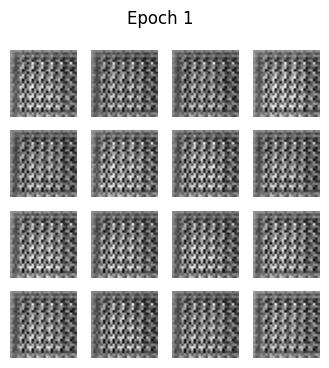

Starting Epoch 2
  Batch 0 | Gen Loss: 1.1658 | Disc Loss: 0.5943
  Batch 20 | Gen Loss: 0.6644 | Disc Loss: 1.2271
  Batch 40 | Gen Loss: 1.0893 | Disc Loss: 0.6149
  Batch 60 | Gen Loss: 1.4910 | Disc Loss: 0.5116
Epoch 2 Completed | Gen Loss: 0.9816 | Disc Loss: 0.7949


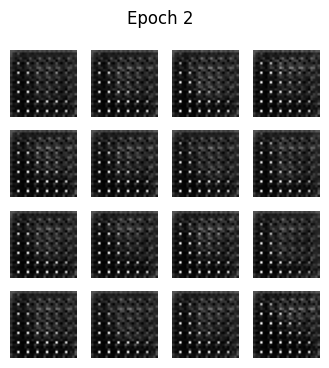

Starting Epoch 3
  Batch 0 | Gen Loss: 1.5597 | Disc Loss: 0.4712
  Batch 20 | Gen Loss: 1.2082 | Disc Loss: 0.6497
  Batch 40 | Gen Loss: 0.9554 | Disc Loss: 1.0031
  Batch 60 | Gen Loss: 1.0572 | Disc Loss: 0.9102
Epoch 3 Completed | Gen Loss: 1.2104 | Disc Loss: 0.7270


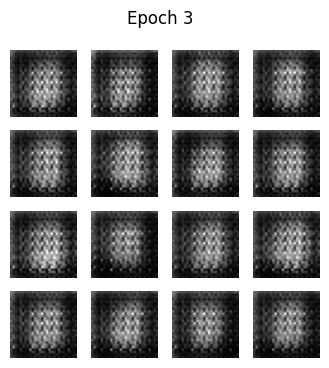

Starting Epoch 4
  Batch 0 | Gen Loss: 0.8292 | Disc Loss: 1.0792
  Batch 20 | Gen Loss: 0.6641 | Disc Loss: 1.5904
  Batch 40 | Gen Loss: 0.7824 | Disc Loss: 1.2541
  Batch 60 | Gen Loss: 0.7590 | Disc Loss: 1.4153
Epoch 4 Completed | Gen Loss: 0.7051 | Disc Loss: 1.3913


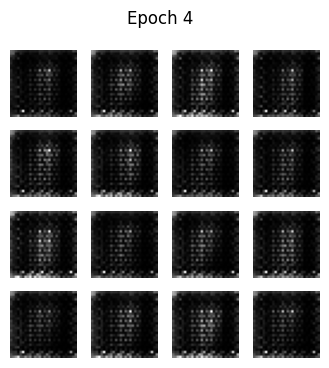

Starting Epoch 5
  Batch 0 | Gen Loss: 0.7861 | Disc Loss: 1.3942
  Batch 20 | Gen Loss: 1.0225 | Disc Loss: 0.8700
  Batch 40 | Gen Loss: 1.1815 | Disc Loss: 0.7854
  Batch 60 | Gen Loss: 0.4561 | Disc Loss: 2.1897
Epoch 5 Completed | Gen Loss: 0.9089 | Disc Loss: 1.1254


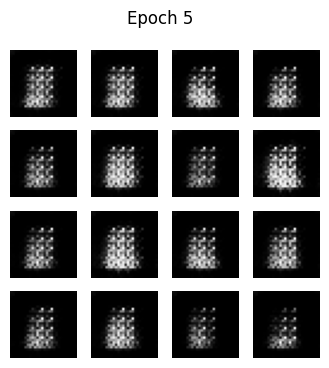

In [10]:
EPOCHS = 5

print("Training started...\n")

for epoch in range(EPOCHS):
    print(f"Starting Epoch {epoch+1}")

    gen_losses = []
    disc_losses = []

    for i, image_batch in enumerate(dataset):
        gen_loss, disc_loss = train_step(image_batch)

        gen_losses.append(gen_loss)
        disc_losses.append(disc_loss)

        # Show progress every few batches
        if i % 20 == 0:
            print(f"  Batch {i} | Gen Loss: {gen_loss:.4f} | Disc Loss: {disc_loss:.4f}")

    print(f"Epoch {epoch+1} Completed | "
          f"Gen Loss: {np.mean(gen_losses):.4f} | "
          f"Disc Loss: {np.mean(disc_losses):.4f}")

    # Show generated images
    generate_images(generator, epoch)

Callbacks => helps us to avoid the overfitting in the models